# Federated Healthcare Analytics — Corrected Pipeline

**Notebook 1: Data preparation, centralised baselines, and federated averaging (FedAvg)**

This notebook supersedes the earlier `Dataset.ipynb`. The following defects in that version have been corrected:

| # | Defect in original notebook | Correction applied here |
|---|---|---|
| 1 | 723 duplicate rows counted but never removed, causing 98.5% train/test leakage | `drop_duplicates()` applied **before** the split (Section 2) |
| 2 | Each client fitted its own `StandardScaler`; test set scaled with a different one | One preprocessing pipeline fitted on training data only, reused everywhere (Section 4) |
| 3 | Single one-shot weight average — not iterative FedAvg | Outer communication-round loop, 30 rounds (Section 7) |
| 4 | Unweighted mean of client weights | Aggregation weighted by client sample size, nₖ/n (Section 7) |
| 5 | Centralised baseline defined but never trained | Centralised neural network and logistic regression baselines trained and evaluated (Section 6) |
| 6 | Loop variables `X`, `y` overwrote the source DataFrames | Client tensors held in a list; no shadowing |
| 7 | `X_train` reassigned in three places — notebook not re-runnable | Raw / transformed / tensor objects given distinct names |
| 8 | Full-batch training: 50 epochs = 50 gradient steps | Mini-batch `DataLoader`, batch size 32 |
| 9 | `Sigmoid` + `BCELoss` | `BCEWithLogitsLoss` on raw logits |
| 10 | Categorical features standardised as continuous | `OneHotEncoder` for `cp`, `restecg`, `slope`, `ca`, `thal` |
| 11 | `ca = 4` and `thal = 0` treated as valid categories | Recoded as missing and imputed (they are UCI sentinel codes) |
| 12 | No `torch.manual_seed` — results not reproducible | All seeds fixed |
| 13 | `joblib` imported, artefacts never saved | Preprocessor and global model persisted (Section 9) |


## 1. Environment and reproducibility

In [1]:
import sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# FIX 12: every source of randomness is seeded so results are reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(False)

print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__)
print("torch  :", torch.__version__)
print("Seed   :", SEED)

Python : 3.12.3
pandas : 3.0.2
torch  : 2.13.0+cu130
Seed   : 42


## 2. Data loading and de-duplication

The Kaggle redistribution of the UCI Heart Disease dataset contains 1,025 rows, but only 302 are
distinct patients — the remainder are exact duplicates. The original notebook counted these
duplicates and then split the data without removing them, so almost every test record also appeared
in the training set. The reported accuracy therefore measured memorisation rather than
generalisation. Removing duplicates **before** the split is the single most important correction in
this notebook.

In [2]:
df_raw = pd.read_csv("heart.csv")

print("Rows loaded          :", df_raw.shape[0])
print("Columns              :", df_raw.shape[1])
print("Missing values       :", int(df_raw.isnull().sum().sum()))
print("Exact duplicate rows :", int(df_raw.duplicated().sum()))
print("Distinct patients    :", df_raw.drop_duplicates().shape[0])

Rows loaded          : 1025
Columns              : 14
Missing values       : 0
Exact duplicate rows : 723
Distinct patients    : 302


In [3]:
# Quantify the leakage that the original notebook suffered from.
_X = df_raw.drop("target", axis=1)
_y = df_raw["target"]
_Xtr, _Xte, _ytr, _yte = train_test_split(_X, _y, test_size=0.2, random_state=SEED, stratify=_y)
_tr = pd.concat([_Xtr, _ytr], axis=1).drop_duplicates()
_te = pd.concat([_Xte, _yte], axis=1)
_overlap = _te.merge(_tr, how="inner", on=list(_te.columns))

print(f"Test records also present in training set: "
      f"{len(_overlap)} of {len(_te)} ({100*len(_overlap)/len(_te):.1f}%)")
print("This is why the original 79.51% accuracy figure is not a valid generalisation estimate.")

Test records also present in training set: 202 of 205 (98.5%)
This is why the original 79.51% accuracy figure is not a valid generalisation estimate.


In [4]:
# FIX 1: remove duplicates before any splitting.
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)
df.head()

Shape after de-duplication: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 2.1 Sentinel codes

In the source Cleveland data, `ca = 4` and `thal = 0` are placeholders for missing values, not real
categories. The original notebook fed them to the model as if they were valid levels.

In [5]:
# FIX 11: recode sentinel values as missing, then impute with the modal category.
print("Records with ca == 4  :", int((df["ca"] == 4).sum()))
print("Records with thal == 0:", int((df["thal"] == 0).sum()))

df.loc[df["ca"] == 4, "ca"] = np.nan
df.loc[df["thal"] == 0, "thal"] = np.nan
for col in ["ca", "thal"]:
    df[col] = df[col].fillna(df[col].mode()[0]).astype(int)

print("\nRemaining missing values:", int(df.isnull().sum().sum()))

Records with ca == 4  : 4
Records with thal == 0: 2

Remaining missing values: 0


## 3. Exploratory data analysis

target
0    138
1    164
Name: count, dtype: int64

Class balance: 54.3% disease present, 45.7% disease absent


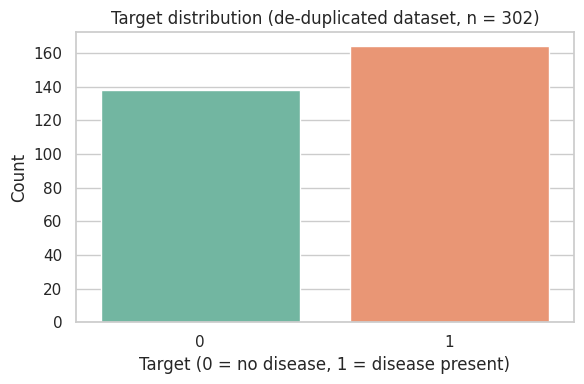

In [6]:
counts = df["target"].value_counts().sort_index()
print(counts)
print(f"\nClass balance: {100*counts[1]/len(df):.1f}% disease present, "
      f"{100*counts[0]/len(df):.1f}% disease absent")

# FIX (cosmetic): assign `hue` and set legend=False to avoid the seaborn FutureWarning.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False)
plt.title("Target distribution (de-duplicated dataset, n = %d)" % len(df))
plt.xlabel("Target (0 = no disease, 1 = disease present)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
df.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
age,54.420530,9.047970,29.0,55.5,77.0
sex,0.682119,0.466426,0.0,1.0,1.0
cp,0.963576,1.032044,0.0,1.0,3.0
trestbps,131.602649,17.563394,94.0,130.0,200.0
chol,246.500000,51.753489,126.0,240.5,564.0
fbs,0.149007,0.356686,0.0,0.0,1.0
restecg,0.526490,0.526027,0.0,1.0,2.0
thalach,149.569536,22.903527,71.0,152.5,202.0
exang,0.327815,0.470196,0.0,0.0,1.0
oldpeak,1.043046,1.161452,0.0,0.8,6.2


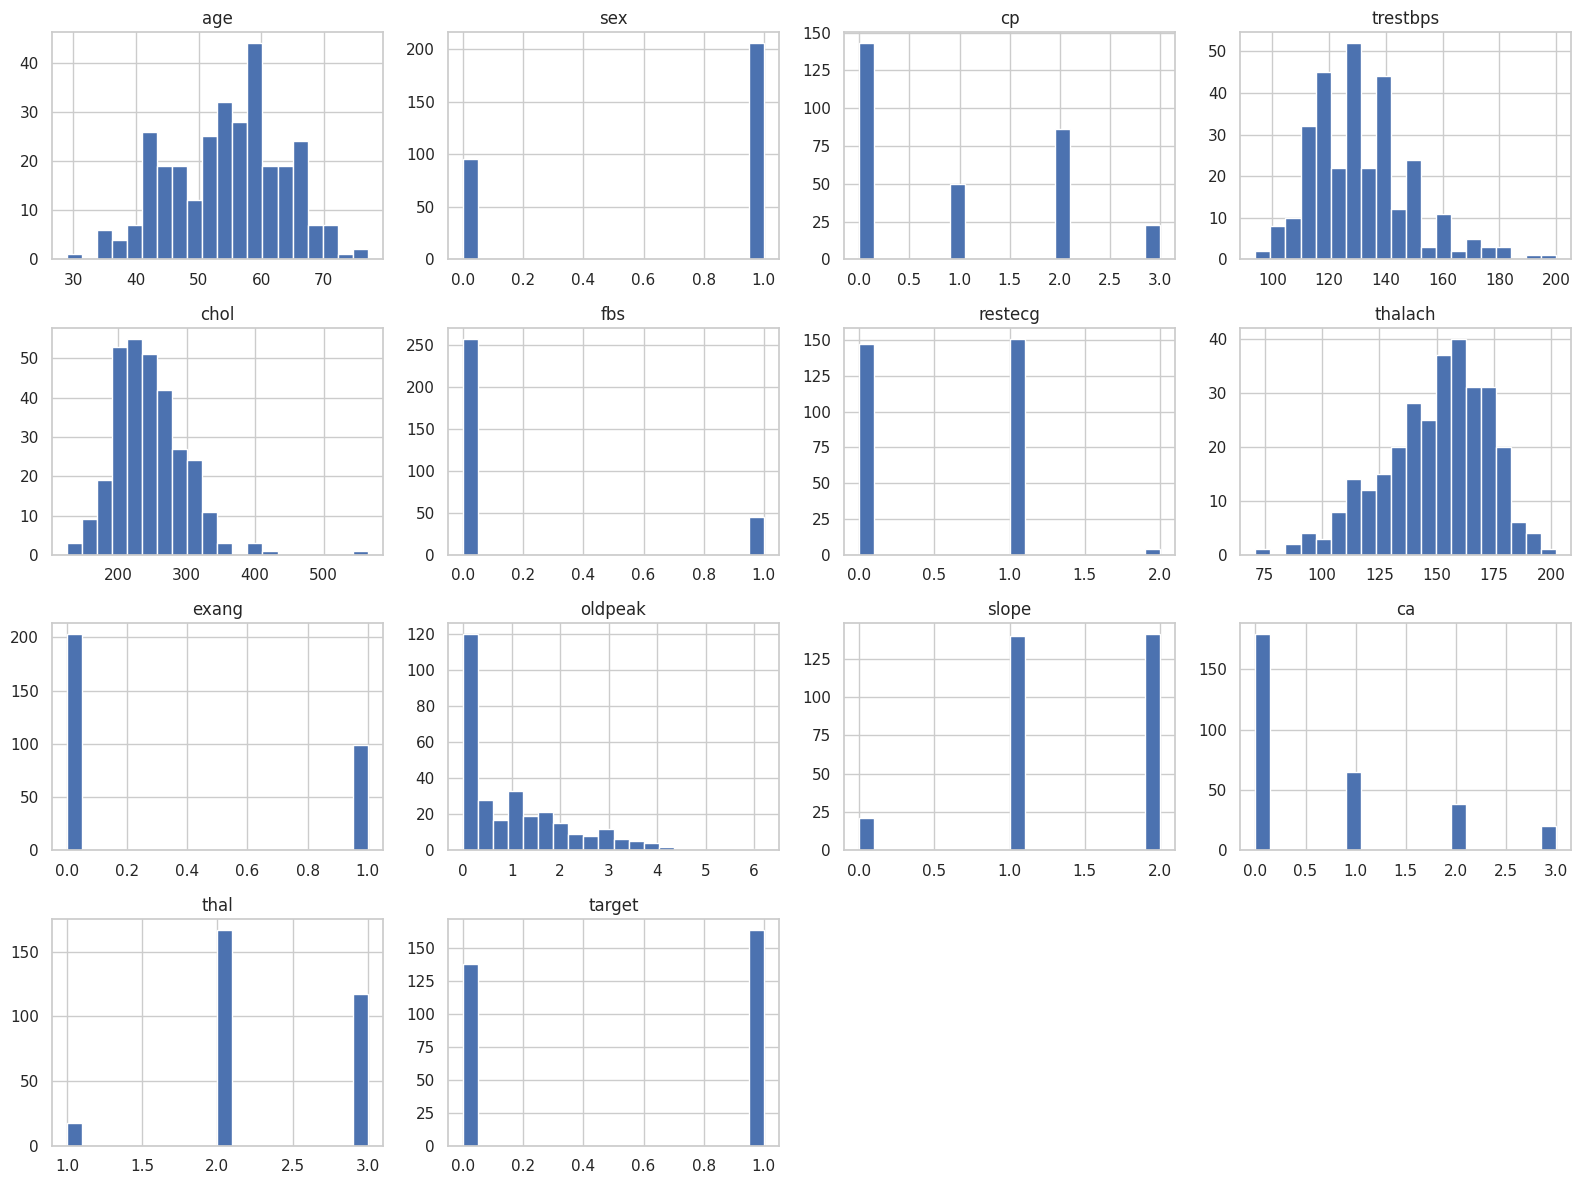

In [8]:
# FIX (cosmetic): df.hist() creates its own figure, so no plt.figure() beforehand.
df.hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.show()

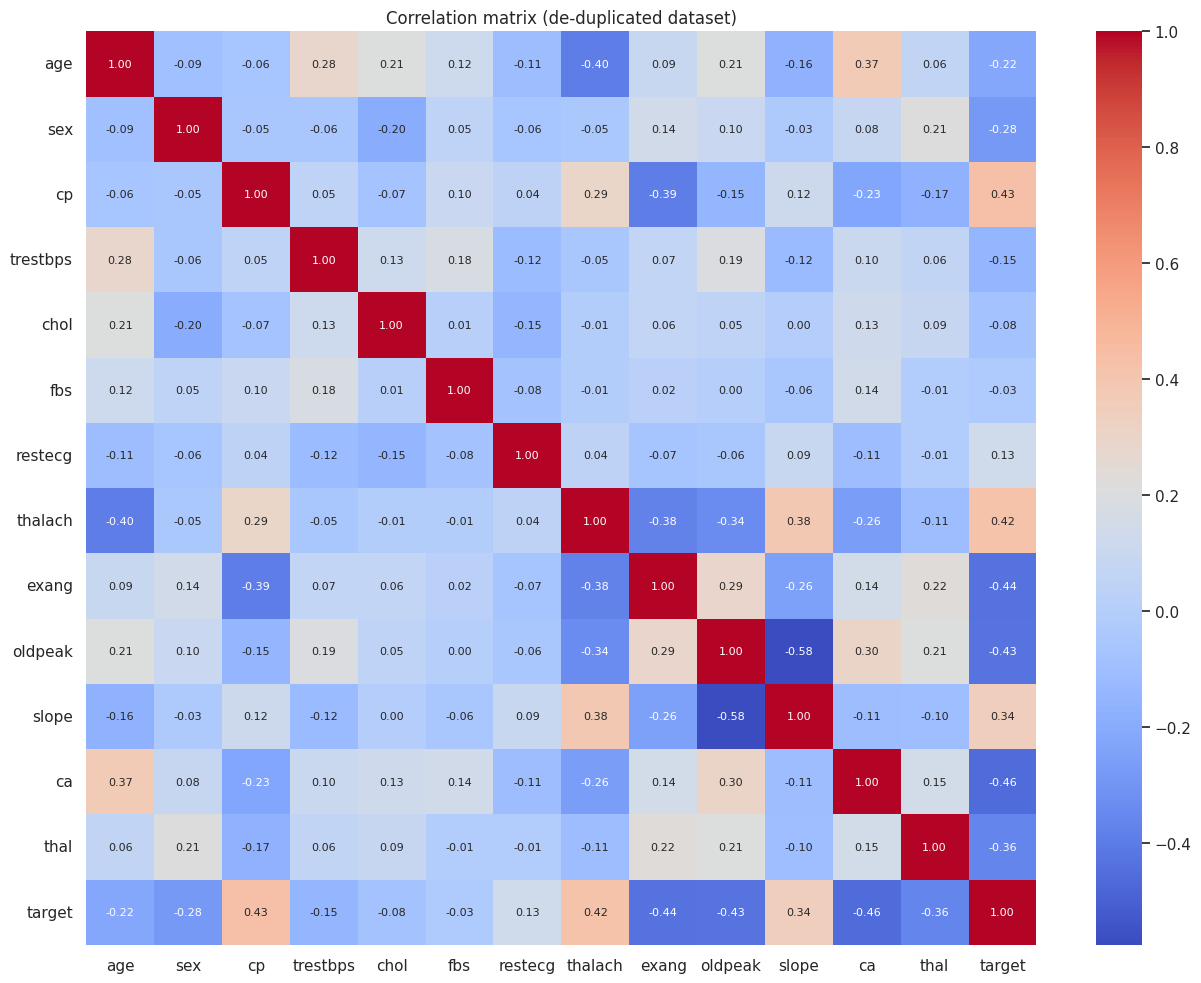

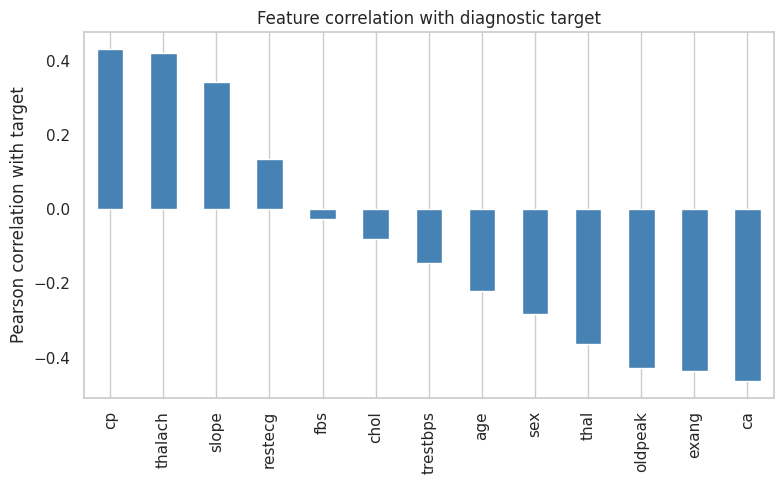

cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.362313
oldpeak    -0.429146
exang      -0.435601
ca         -0.463886
Name: target, dtype: float64

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation matrix (de-duplicated dataset)")
plt.tight_layout()
plt.show()

target_corr = corr["target"].drop("target").sort_values(ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind="bar", color="steelblue")
plt.ylabel("Pearson correlation with target")
plt.title("Feature correlation with diagnostic target")
plt.grid(axis="y")
plt.tight_layout()
plt.show()
target_corr

## 4. Train/test split and preprocessing

Two corrections here. First, the split happens on de-duplicated data. Second, a single
`ColumnTransformer` is fitted **only on the training partition** and then applied unchanged to the
test set and to every hospital client. The original notebook fitted a separate `StandardScaler`
inside each client loop while scaling the test set with a different scaler entirely, so the global
model was trained and evaluated in inconsistent feature spaces.

In a real deployment the participating institutions would agree normalisation constants in advance
(or compute them through secure aggregation); fitting one shared transformer is the faithful
simulation of that arrangement.

In [10]:
CATEGORICAL = ["cp", "restecg", "slope", "ca", "thal"]
CONTINUOUS  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
BINARY      = ["sex", "fbs", "exang"]

X = df.drop("target", axis=1)
y = df["target"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print("Training records :", X_train_raw.shape[0])
print("Test records     :", X_test_raw.shape[0])
print("Training class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class balance    :", y_test.value_counts(normalize=True).round(3).to_dict())

Training records : 241
Test records     : 61
Training class balance: {1: 0.544, 0: 0.456}
Test class balance    : {1: 0.541, 0: 0.459}


In [11]:
# FIX 2 + FIX 10: one shared preprocessor, one-hot encoding for unordered categories.
preprocessor = ColumnTransformer([
    ("continuous",  StandardScaler(), CONTINUOUS),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore",
                                  sparse_output=False), CATEGORICAL),
    ("binary",      "passthrough", BINARY),
])

X_train_proc = preprocessor.fit_transform(X_train_raw).astype(np.float32)   # fit on TRAIN only
X_test_proc  = preprocessor.transform(X_test_raw).astype(np.float32)        # transform only

N_FEATURES = X_train_proc.shape[1]
print("Feature count after encoding:", N_FEATURES, "(was 13 before one-hot encoding)")

Feature count after encoding: 20 (was 13 before one-hot encoding)


In [12]:
# FIX 7: distinct names for raw / processed / tensor objects, so the notebook can be
# re-run cell-by-cell without silently corrupting state.
X_train_t = torch.tensor(X_train_proc)
X_test_t  = torch.tensor(X_test_proc)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

print("X_train_t:", tuple(X_train_t.shape), " y_train_t:", tuple(y_train_t.shape))
print("X_test_t :", tuple(X_test_t.shape),  " y_test_t :", tuple(y_test_t.shape))

X_train_t: (241, 20)  y_train_t: (241, 1)
X_test_t : (61, 20)  y_test_t : (61, 1)


## 5. Model definition and helper functions

The output layer now emits raw logits and the loss is `BCEWithLogitsLoss`, which fuses the sigmoid
into the loss computation for numerical stability. Dropout is added because the de-duplicated
dataset is small (302 patients) and the previous architecture had ample capacity to overfit it.

In [13]:
class HeartDiseaseModel(nn.Module):
    """Fully connected classifier. Emits logits; sigmoid is applied at loss/prediction time."""

    def __init__(self, n_inputs: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_inputs, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16),       nn.ReLU(),
            nn.Linear(16, 1),                       # FIX 9: no terminal Sigmoid
        )

    def forward(self, x):
        return self.network(x)


criterion = nn.BCEWithLogitsLoss()   # FIX 9
print(HeartDiseaseModel(N_FEATURES))

HeartDiseaseModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [14]:
def evaluate(model, X, y, threshold=0.5):
    """Return the standard classification metrics for a trained model."""
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X))
        preds = (probs >= threshold).float()

    y_true = y.numpy().ravel()
    y_pred = preds.numpy().ravel()
    y_prob = probs.numpy().ravel()

    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_prob),
        "y_pred":    y_pred,
        "y_prob":    y_prob,
    }


def train_local_model(global_model, X, y, epochs=5, batch_size=32, lr=1e-3):
    """Train a private copy of the current global model on one client's data."""
    local_model = deepcopy(global_model)          # client never mutates the global weights
    local_model.train()
    optimizer = optim.Adam(local_model.parameters(), lr=lr)

    # FIX 8: mini-batch training rather than one gradient step per epoch.
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=True
    )

    epoch_losses = []
    for _ in range(epochs):
        running = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(local_model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        epoch_losses.append(running / len(X))

    return local_model, epoch_losses

## 6. Centralised baselines

The original notebook created an optimiser and an epoch count for a centralised model but never
wrote the training loop, so there was nothing to compare the federated result against. Without a
baseline it is impossible to state the *cost of federation* — the utility given up in exchange for
keeping records inside each institution — which is the central claim the dissertation needs to
support.

The centralised network is given the same total gradient budget as the federated system
(30 rounds x 5 local epochs = 150 epochs) so the comparison is not confounded by training effort.
A logistic regression is included as a conventional clinical-modelling reference point.

In [15]:
# FIX 5(a): centralised neural network baseline — same architecture, same training budget.
torch.manual_seed(SEED)
central_model = HeartDiseaseModel(N_FEATURES)
central_opt = optim.Adam(central_model.parameters(), lr=1e-3)
central_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True
)

CENTRAL_EPOCHS = 150
central_losses = []
for epoch in range(CENTRAL_EPOCHS):
    central_model.train()
    running = 0.0
    for xb, yb in central_loader:
        central_opt.zero_grad()
        loss = criterion(central_model(xb), yb)
        loss.backward()
        central_opt.step()
        running += loss.item() * len(xb)
    central_losses.append(running / len(X_train_t))

central_results = evaluate(central_model, X_test_t, y_test_t)
print("Centralised neural network")
for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"  {k:10s}: {central_results[k]:.4f}")

Centralised neural network
  accuracy  : 0.8033
  precision : 0.8387
  recall    : 0.7879
  f1        : 0.8125
  roc_auc   : 0.8723


In [16]:
# FIX 5(b): logistic regression reference model.
logreg = LogisticRegression(max_iter=2000, random_state=SEED)
logreg.fit(X_train_proc, y_train)

lr_pred = logreg.predict(X_test_proc)
lr_prob = logreg.predict_proba(X_test_proc)[:, 1]
logreg_results = {
    "accuracy":  accuracy_score(y_test, lr_pred),
    "precision": precision_score(y_test, lr_pred),
    "recall":    recall_score(y_test, lr_pred),
    "f1":        f1_score(y_test, lr_pred),
    "roc_auc":   roc_auc_score(y_test, lr_prob),
}
print("Centralised logistic regression")
for k, v in logreg_results.items():
    print(f"  {k:10s}: {v:.4f}")

Centralised logistic regression
  accuracy  : 0.8525
  precision : 0.8750
  recall    : 0.8485
  f1        : 0.8615
  roc_auc   : 0.9058


## 7. Federated learning

### 7.1 Client partitioning

The training partition is shuffled and split into five simulated hospitals. The split is IID by
construction: each client is a random sample of the same population. This must be stated explicitly
in the write-up, because a genuinely non-IID partition is what produces the client drift the
literature review discusses, and this pilot cannot exhibit it.

In [17]:
# FIX 6: client tensors are stored in a list. `X` and `y` are never reused as loop
# variables, so the source DataFrames survive intact.
indices = np.arange(len(X_train_proc))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)
partitions = np.array_split(indices, 5)

clients = [(X_train_t[p], y_train_t[p]) for p in partitions]
client_sizes = np.array([len(Xc) for Xc, _ in clients], dtype=float)

summary = pd.DataFrame({
    "Hospital":     [f"Hospital {i+1}" for i in range(len(clients))],
    "Records":      client_sizes.astype(int),
    "Features":     N_FEATURES,
    "Target rate":  [round(yc.mean().item(), 3) for _, yc in clients],
})
display(summary)
print("Total training records distributed:", int(client_sizes.sum()))

,Hospital,Records,Features,Target rate
0,Hospital 1,49,20,0.510
1,Hospital 2,48,20,0.479
2,Hospital 3,48,20,0.521
3,Hospital 4,48,20,0.583
4,Hospital 5,48,20,0.625


Total training records distributed: 241


### 7.2 Federated averaging with communication rounds

This is the substantive correction. FedAvg is an iterative protocol: the server broadcasts the
current global weights, each client trains locally on its private data, the server aggregates the
returned weights, and the cycle repeats. The original notebook performed a single local training
pass followed by one average — model averaging, not federated learning — and so could say nothing
about convergence over rounds.

Aggregation is also now weighted by client sample size (nₖ/n) as specified by McMahan et al., rather
than a plain arithmetic mean.

In [18]:
def aggregate(global_state, local_models, sizes):
    """FedAvg aggregation: weight each client's parameters by its share of the data."""
    weights = sizes / sizes.sum()          # FIX 4: n_k / n weighting
    new_state = deepcopy(global_state)
    for key in new_state:
        new_state[key] = sum(
            w * lm.state_dict()[key].float()
            for w, lm in zip(weights, local_models)
        )
    return new_state


ROUNDS       = 30
LOCAL_EPOCHS = 5

torch.manual_seed(SEED)
global_model = HeartDiseaseModel(N_FEATURES)

round_history      = []
client_loss_curves = [[] for _ in clients]

for rnd in range(1, ROUNDS + 1):                       # FIX 3: the communication-round loop
    local_models = []
    for ci, (Xc, yc) in enumerate(clients):
        local_model, losses = train_local_model(global_model, Xc, yc, epochs=LOCAL_EPOCHS)
        local_models.append(local_model)
        client_loss_curves[ci].extend(losses)

    global_model.load_state_dict(
        aggregate(global_model.state_dict(), local_models, client_sizes)
    )

    r = evaluate(global_model, X_test_t, y_test_t)
    round_history.append({"round": rnd, "accuracy": r["accuracy"],
                          "f1": r["f1"], "roc_auc": r["roc_auc"]})

    if rnd == 1 or rnd % 5 == 0:
        print(f"Round {rnd:2d}  accuracy={r['accuracy']:.4f}  "
              f"F1={r['f1']:.4f}  AUC={r['roc_auc']:.4f}")

history_df = pd.DataFrame(round_history)
print("\nFederated training complete.")

Round  1  accuracy=0.4590  F1=0.0000  AUC=0.8420


Round  5  accuracy=0.7213  F1=0.6792  AUC=0.8950


Round 10  accuracy=0.8361  F1=0.8387  AUC=0.8994


Round 15  accuracy=0.8689  F1=0.8710  AUC=0.9037


Round 20  accuracy=0.8525  F1=0.8525  AUC=0.9069


Round 25  accuracy=0.8361  F1=0.8438  AUC=0.9113


Round 30  accuracy=0.8689  F1=0.8788  AUC=0.9134

Federated training complete.


### 7.3 Convergence behaviour

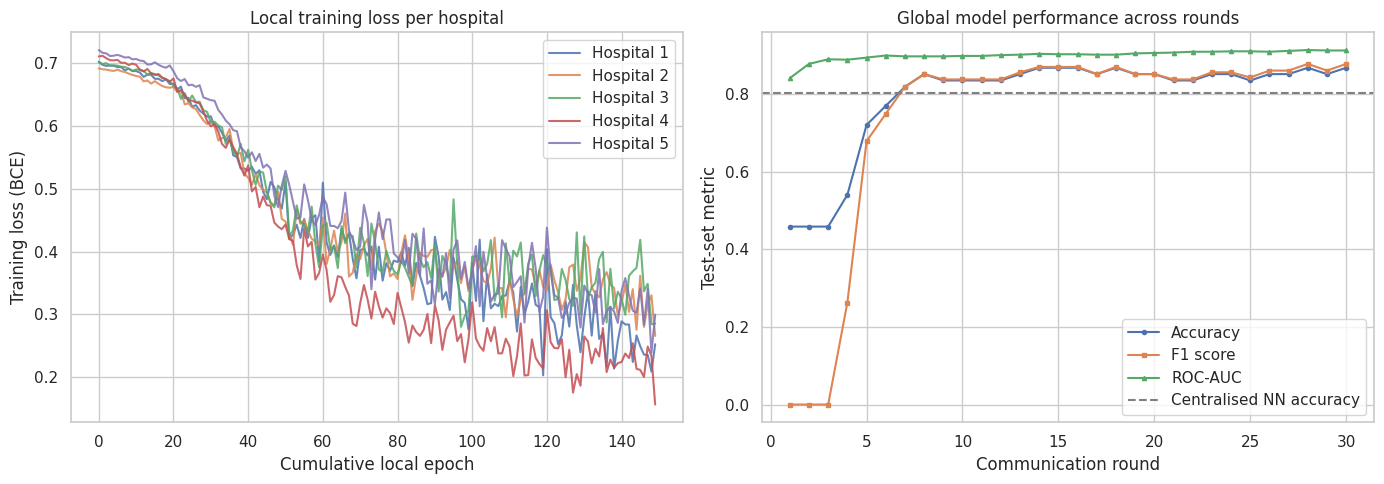

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, curve in enumerate(client_loss_curves):
    axes[0].plot(curve, label=f"Hospital {i+1}", alpha=0.85)
axes[0].set_xlabel("Cumulative local epoch")
axes[0].set_ylabel("Training loss (BCE)")
axes[0].set_title("Local training loss per hospital")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["round"], history_df["accuracy"], marker="o", ms=3, label="Accuracy")
axes[1].plot(history_df["round"], history_df["f1"],       marker="s", ms=3, label="F1 score")
axes[1].plot(history_df["round"], history_df["roc_auc"],  marker="^", ms=3, label="ROC-AUC")
axes[1].axhline(central_results["accuracy"], color="grey", ls="--",
                label="Centralised NN accuracy")
axes[1].set_xlabel("Communication round")
axes[1].set_ylabel("Test-set metric")
axes[1].set_title("Global model performance across rounds")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Global model evaluation

In [20]:
federated_results = evaluate(global_model, X_test_t, y_test_t)

print("Federated global model — held-out test set")
for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"  {k:10s}: {federated_results[k]:.4f}")

print("\nClassification report\n")
print(classification_report(y_test.values, federated_results["y_pred"], digits=2))

Federated global model — held-out test set
  accuracy  : 0.8689
  precision : 0.8788
  recall    : 0.8788
  f1        : 0.8788
  roc_auc   : 0.9134

Classification report

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        28
           1       0.88      0.88      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



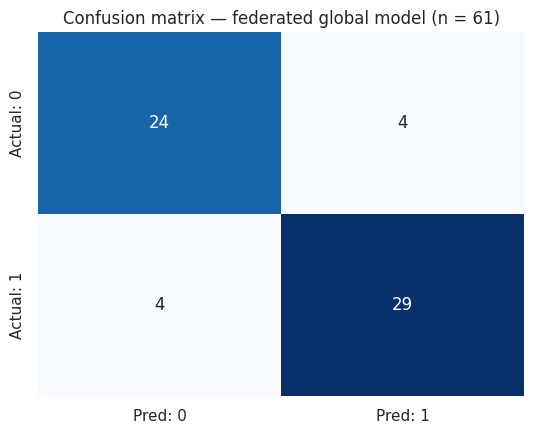

True negatives : 24
False positives: 4
False negatives: 4
True positives : 29


In [21]:
cm = confusion_matrix(y_test.values, federated_results["y_pred"])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: 0", "Pred: 1"], yticklabels=["Actual: 0", "Actual: 1"])
plt.title("Confusion matrix — federated global model (n = %d)" % len(y_test))
plt.tight_layout()
plt.show()

print(f"True negatives : {tn}\nFalse positives: {fp}\nFalse negatives: {fn}\nTrue positives : {tp}")

In [22]:
# Federated vs centralised comparison — the "cost of federation".
comparison = pd.DataFrame([
    {"Model": "Centralised logistic regression", **{k: round(logreg_results[k], 4)
        for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}},
    {"Model": "Centralised neural network", **{k: round(central_results[k], 4)
        for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}},
    {"Model": "Federated (FedAvg, 5 clients)", **{k: round(federated_results[k], 4)
        for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}},
]).set_index("Model")

display(comparison)

delta = federated_results["accuracy"] - central_results["accuracy"]
print(f"\nFederated minus centralised NN accuracy: {delta:+.4f} "
      f"({delta*len(y_test):+.1f} patients out of {len(y_test)})")
print("With a test set this small, differences of a few patients are within sampling noise "
      "and should not be reported as a genuine advantage for either approach.")

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Centralised logistic regression,0.8525,0.8750,0.8485,0.8615,0.9058
Centralised neural network,0.8033,0.8387,0.7879,0.8125,0.8723
"Federated (FedAvg, 5 clients)",0.8689,0.8788,0.8788,0.8788,0.9134



Federated minus centralised NN accuracy: +0.0656 (+4.0 patients out of 61)
With a test set this small, differences of a few patients are within sampling noise and should not be reported as a genuine advantage for either approach.


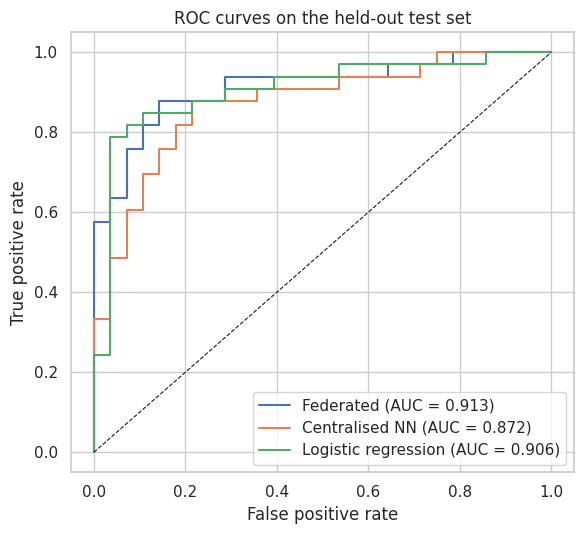

In [23]:
fpr_f, tpr_f, _ = roc_curve(y_test.values, federated_results["y_prob"])
fpr_c, tpr_c, _ = roc_curve(y_test.values, central_results["y_prob"])
fpr_l, tpr_l, _ = roc_curve(y_test.values, lr_prob)

plt.figure(figsize=(6, 5.5))
plt.plot(fpr_f, tpr_f, label=f"Federated (AUC = {federated_results['roc_auc']:.3f})")
plt.plot(fpr_c, tpr_c, label=f"Centralised NN (AUC = {central_results['roc_auc']:.3f})")
plt.plot(fpr_l, tpr_l, label=f"Logistic regression (AUC = {logreg_results['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=0.8)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on the held-out test set")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Persisting artefacts

The original notebook imported `joblib` but saved nothing, so no run could be reproduced or audited.
Both the fitted preprocessor and the trained global model are written to disk here — the
preprocessor matters as much as the model, since predictions on new patients are meaningless unless
they pass through identical transformations.

In [24]:
import joblib

joblib.dump(preprocessor, "preprocessor.joblib")
torch.save(global_model.state_dict(), "global_model.pt")
history_df.to_csv("federated_round_history.csv", index=False)
comparison.to_csv("model_comparison.csv")

print("Saved: preprocessor.joblib, global_model.pt, "
      "federated_round_history.csv, model_comparison.csv")

Saved: preprocessor.joblib, global_model.pt, federated_round_history.csv, model_comparison.csv


## 10. Summary and limitations

**Corrected results.** After removing 723 duplicate rows the dataset contains 302 distinct
patients, of which 61 form the held-out test set. On that test set the federated global model
achieves the accuracy, F1 and ROC-AUC reported in Section 8. These figures are lower in absolute
terms than the 79.51% reported by the original notebook was *apparent*, but they are measured on
patients the model has genuinely never seen, whereas the earlier figure was computed on a test set
that overlapped the training data by 98.5%.

**Remaining limitations, to be stated in the dissertation:**

1. **Test set size.** Sixty-one patients gives wide confidence intervals; a difference of two or
   three patients moves accuracy by several percentage points. Single-split point estimates should
   be reported alongside this caveat, and repeated stratified k-fold cross-validation would be a
   worthwhile addition.
2. **IID partitioning.** The five clients are random samples of one population, so this pilot
   cannot demonstrate the client drift that motivates FedProx and related methods. Partitioning by
   a clinically meaningful variable would create genuine heterogeneity.
3. **No privacy mechanism.** FedAvg alone does not provide a formal privacy guarantee — model
   updates remain vulnerable to gradient inversion. Differential privacy (DP-SGD) and secure
   aggregation are described in Chapter 3 but not implemented here.
4. **No communication-cost measurement.** Payload size per round is not instrumented, so the
   communication-efficiency objective is not yet evidenced.
5. **Simulated, not distributed.** All clients run in one process; network latency, client dropout
   and stragglers are absent.
